## **Solving First-Order ODEs**

**Method 1.** The next code used Method 1, namely the custom loss enforces the differential equation to hold at certain colocation points. We train the network for 200 epochs and consider the initial condition weighted with w=10 for accuracy reasons.  

I0000 00:00:1783736616.237943    9352 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783736617.756208    9352 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783736624.073119    9352 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/efra/anaconda3/envs/dl4physics/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1783736626.643414    9352 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA er

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


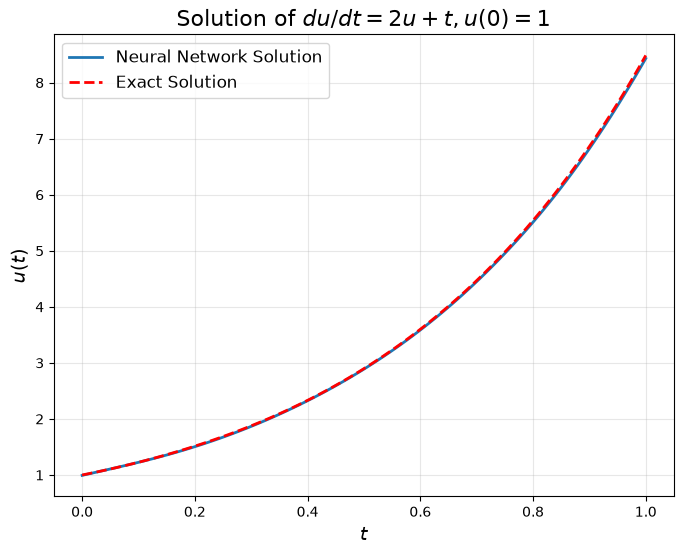

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Define the exact solution for comparison
def exact_solution(t):
    return  (5*np.exp(2*t)-2*t-1)/4

# Define the function F(u, t) = 2*u + t
def F(u, t):
    return 2 * u + t

# Neural network to approximate u(t)
model = Sequential([
    Dense(50, activation='tanh', input_dim=1),  # Hidden layer with 50 neurons
    Dense(50, activation='tanh'),              # Another hidden layer
    Dense(1)                                   # Output layer
])

# Custom loss function
def custom_loss(y_true, y_pred):
    t_input = tf.constant(t_train, dtype=tf.float32)  # Training points
    u_pred = model(t_input)  # Predicted u(t)

    # Compute du/dt using automatic differentiation
    with tf.GradientTape() as tape:
        tape.watch(t_input)
        u_t = model(t_input)
    du_dt = tape.gradient(u_t, t_input)

    # Boundary condition loss
    boundary_loss = tf.square(model(tf.constant([[0.0]])) - 1.0)  # u(0) = 1

    # Equation loss
    equation_loss = tf.reduce_mean(tf.square(du_dt - F(u_pred, t_input)))

    # Total loss
    return 10*boundary_loss + equation_loss

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)

# Generate training data: time points in [0, 2]
t_train = np.linspace(0, 1, 100).reshape(-1, 1)
dummy_target = np.zeros_like(t_train)  # Dummy target, as the loss handles everything

# Train the model
model.fit(t_train, dummy_target, epochs=200, batch_size=32, verbose=0)

# Generate points for plotting
t_plot = np.linspace(0, 1, 100).reshape(-1, 1)
u_nn = model.predict(t_plot)  # Neural network solution
u_exact = exact_solution(t_plot)  # Exact solution

# Plot the solutions
plt.figure(figsize=(8, 6))
plt.plot(t_plot, u_nn, label="Neural Network Solution", linewidth=2)
plt.plot(t_plot, u_exact, label="Exact Solution", linewidth=2, color='red', linestyle='dashed')
plt.title("Solution of $du/dt = 2u + t, u(0) = 1$", fontsize=16)
plt.xlabel("$t$", fontsize=14)
plt.ylabel("$u(t)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


**Method 2.** The next code used Method 2, namely we use the trial solution $u(t) = u_0 + t NN(t, \theta)$. Even if we train the network for only 50 epochs we obtain better learning than in the case of the previous Method 1.  

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


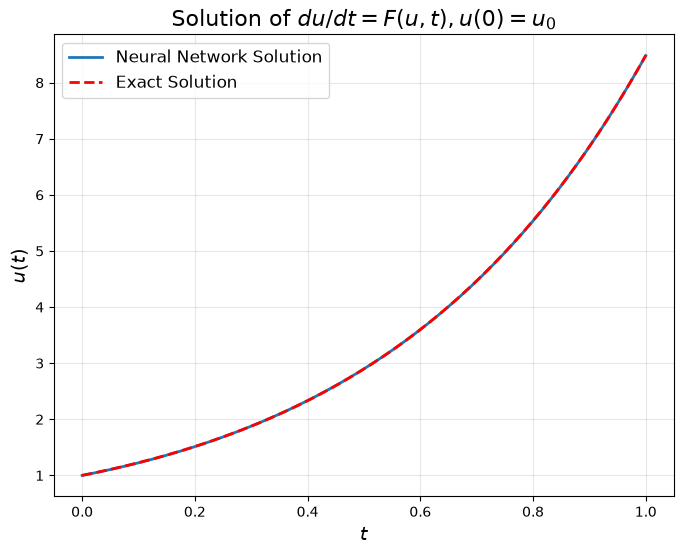

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Define the function F(u, t) (adjustable to any problem)
def F(u, t):
    return 2 * u + t  # Example: Replace with any specific function

# Define the initial condition u(0) = u_0
u_0 = 1.0

# Neural network to approximate the correction term NN(theta, t)
model = Sequential([
    Dense(50, activation='tanh', input_dim=1),  # Hidden layer with 50 neurons
    Dense(50, activation='tanh'),              # Another hidden layer
    Dense(1)                                   # Output layer
])

# Custom loss function
def custom_loss(y_true, y_pred):
    t_input = tf.constant(t_train, dtype=tf.float32)  # Training points
    nn_t = model(t_input)  # NN(theta, t)

    # Compute u(t) = u_0 + t * NN(theta, t)
    u_t = u_0 + t_input * nn_t

    # Compute du/dt = NN(theta, t) + t * d(NN(theta, t))/dt
    with tf.GradientTape() as tape:
        tape.watch(t_input)
        nn_t_gradient = model(t_input)
    d_nn_dt = tape.gradient(nn_t_gradient, t_input)
    du_dt = nn_t + t_input * d_nn_dt

    # Residual of the ODE: du/dt - F(u, t)
    residual = du_dt - F(u_t, t_input)
    return tf.reduce_mean(tf.square(residual))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)

# Generate training data: time points in [0, 1]
t_train = np.linspace(0, 1, 100).reshape(-1, 1)
dummy_target = np.zeros_like(t_train)  # Dummy target, as the loss handles everything

# Train the model
model.fit(t_train, dummy_target, epochs=50, batch_size=32, verbose=0)

# Generate points for plotting
t_plot = np.linspace(0, 1, 100).reshape(-1, 1)
u_nn = u_0 + t_plot * model.predict(t_plot)  # Neural network solution

# Example: Replace with exact solution for comparison if known
# Here, using a placeholder for comparison (replace with real function if available)
u_exact = (5*np.exp(2 * t_plot) - 2*t_plot - 1)/4  # Example: Exact solution for F(u, t) = 2u + t

# Plot the solutions
plt.figure(figsize=(8, 6))
plt.plot(t_plot, u_nn, label="Neural Network Solution", linewidth=2)
plt.plot(t_plot, u_exact, label="Exact Solution", linewidth=2, color='red', linestyle='dashed')
plt.title("Solution of $du/dt = F(u, t), u(0) = u_0$", fontsize=16)
plt.xlabel("$t$", fontsize=14)
plt.ylabel("$u(t)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

